# NB17 — Negotiation-Spread Table (CPT 73721)

**The rate ladder that NB16's confirmed markups feed into.** This notebook assembles the
per-hospital spread table — Medicare floor / Medicaid / commercial / cash(chargemaster) —
and computes the spread ratios that are the backbone the Streamlit app renders.

Continues NB16 (insurance-negotiation factor). NB16 supplied the *commercial* rung as a
markup-over-floor proxy; NB17 places that rung beside the other three to show the full
payer ladder and the spreads between rungs.

**Inherited contract (do not break):**
- Hospital `short` names match NB13's loader / NB16's roster (the join key).
- `floor = 243.77` (national OPPS, CY2026) headline; `floor_dfw = 238.65` (DFW-adj) sensitivity.
- Two locks carried from NB16: per-hospital gate (Methodist + Parkland withheld) **and**
  the global `MEDIANS_PUBLISHABLE` flag. `is_publishable()` is the single publish chokepoint.
- Gated rungs carry `NaN`/`None`, never a fabricated number. Real-but-gated output is stamped
  **"DRAFT — NOT PUBLISHABLE"**; synthetic output is stamped **`[SYNTHETIC DATA]`** (Decision 52).

Run mode: **Restart & Run All** (canonical). Single-cell runs trip run-order NameErrors by design.


## Step 0 — Environment & hardened path resolver

Reuse NB16's hardened resolver verbatim. Identify the project by a **unique signature**
(`src/queries.py`) plus explicit `Documents\dfw-hospital-pricing` candidates — *not* a bare
`.git`/`data` marker (that hijacked the walk-up to `C:\Users\kedha` on Day 22).

This cell should:
- resolve `ROOT` and print it,
- resolve `RAW_DIR` by checking which candidate actually contains the 5 `.duckdb` files, print the choice,
- put `ROOT` (not `SRC`) on `sys.path`; confirm `from src import queries` and that
  `add_lob_v4` + `query_procedure_rates_agg` are exported,
- define the constants: `FLOOR = 243.77`, `FLOOR_DFW = 238.65`, `MEDIANS_PUBLISHABLE = False`,
  `SPREAD_BASIS = 'proxy'`.


In [4]:
# ── NB17 · Step 0 — Environment & hardened path resolver ────────────────────
# Identify the project by a UNIQUE signature (src/queries.py), never a bare
# .git/data marker (that walked up to C:\Users\kedha on Day 22). Resolve RAW_DIR
# by checking which candidate actually holds the 5 .duckdb files. Restart & Run All.

import sys
from pathlib import Path

PROJECT_SIGNATURE = Path("src") / "queries.py"   # unique to this project, can't be spoofed

def _find_root() -> Path:
    candidates = []
    # 1) walk up from cwd looking for the signature
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / PROJECT_SIGNATURE).is_file():
            candidates.append(p)
            break
    # 2) explicit absolute fallbacks (kernel launched from anywhere)
    for c in (
        Path(r"C:\Users\kedha\Documents\dfw-hospital-pricing"),
        Path.home() / "Documents" / "dfw-hospital-pricing",
    ):
        if (c / PROJECT_SIGNATURE).is_file():
            candidates.append(c.resolve())
    if not candidates:
        raise RuntimeError(
            f"Could not locate project root (no {PROJECT_SIGNATURE} found). "
            f"cwd={here}"
        )
    return candidates[0]

ROOT = _find_root()

def _find_raw_dir(root: Path) -> Path:
    # RAW_DIR is whichever candidate actually CONTAINS the .duckdb files
    # (ROOT can land in notebooks/ depending on kernel cwd — check, don't assume).
    for cand in (root / "data" / "raw", root.parent / "data" / "raw"):
        if cand.is_dir() and list(cand.glob("*.duckdb")):
            return cand.resolve()
    raise RuntimeError(f"No *.duckdb found under {root/'data'/'raw'} or its parent.")

RAW_DIR = _find_raw_dir(ROOT)

# ROOT (not SRC) on sys.path → `from src import queries` is the canonical form
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import queries
_exports = [n for n in ("add_lob_v4", "query_procedure_rates_agg") if hasattr(queries, n)]
_missing = [n for n in ("add_lob_v4", "query_procedure_rates_agg") if not hasattr(queries, n)]

# ── Constants (the contract NB17 runs under) ────────────────────────────────
FLOOR             = 243.77     # national OPPS, CY2026 — headline floor benchmark
FLOOR_DFW         = 238.65     # DFW-adjusted — labeled sensitivity only
MEDIANS_PUBLISHABLE = False    # global publish lock (flip ONLY after Methodist cleanup)
SPREAD_BASIS      = "proxy"    # commercial spread = negotiation-leverage proxy, NOT a margin

# ── Self-report ─────────────────────────────────────────────────────────────
_dbs = sorted(RAW_DIR.glob("*.duckdb"))
print("ROOT      :", ROOT)
print("RAW_DIR   :", RAW_DIR)
print(f".duckdb   : {len(_dbs)} files")
for p in _dbs:
    print("            -", p.name)
print("queries   : exports OK ->", _exports, ("| MISSING -> " + str(_missing)) if _missing else "")
print(f"floor     : {FLOOR}  (DFW-adj {FLOOR_DFW})")
print(f"locks     : MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}  SPREAD_BASIS='{SPREAD_BASIS}'")
assert not _missing, f"queries.py missing required exports: {_missing}"
assert len(_dbs) == 5, f"expected 5 .duckdb files, found {len(_dbs)}"
print("\nStep 0 OK.")

ROOT      : C:\Users\kedha\Documents\dfw-hospital-pricing
RAW_DIR   : C:\Users\kedha\Documents\dfw-hospital-pricing\data\raw
.duckdb   : 5 files
            - baylor_university_medical_center-69947_parsed.duckdb
            - medical_city_alliance_hospital-77912_parsed.duckdb
            - methodist_dallas_medical_center-6000b_parsed.duckdb
            - parkland_health-6e88d_parsed.duckdb
            - texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb
queries   : exports OK -> ['add_lob_v4', 'query_procedure_rates_agg'] 
floor     : 243.77  (DFW-adj 238.65)
locks     : MEDIANS_PUBLISHABLE=False  SPREAD_BASIS='proxy'

Step 0 OK.


## Step 1 — Roster + rung definitions

The five-hospital roster keyed by the same `short` names NB13 stamps (Baylor, MCA, Methodist,
Parkland, THP), carrying county / ownership / safety-net regime (the Decision-45 structure).

Define the **four rate rungs** of the ladder as an explicit, ordered contract so the table
columns are stable and self-documenting:
- `medicare`  — the floor benchmark ($243.77; administered near cost-recovery).
- `medicaid`  — Medicaid / Medicaid-managed rung (expect near or below the floor).
- `commercial`— the negotiated commercial rung (sourced from NB16's confirmed medians).
- `cash`      — cash / chargemaster rung (the ceiling; MCA's ~$8,364 lives here).

Name the two gated hospitals (Methodist, Parkland) in the data itself, with the gate reason,
so downstream cells read the gate from the roster, not from memory.


In [5]:
# ── NB17 · Step 1 — Roster + rung definitions ───────────────────────────────
# Roster keyed by the SAME `short` names NB13's loader stamps (the join key).
# Carries county / ownership / safety-net regime (Decision-45 structure) and
# names the two gated hospitals IN THE DATA, with the gate reason, so every
# downstream cell reads the gate from here — not from memory.

import pandas as pd

# CCNs are corroborated (cross-checked) but not yet confirmed against the literal
# PUF row — carried open item; not load-bearing for the spread table.
ROSTER = pd.DataFrame([
    # short,       name,                                          ccn,      county,    ownership,    safety_net, gated, gate_reason
    ("Baylor",     "Baylor University Medical Center",            "450021", "Dallas",  "nonprofit",  "Parkland", False, None),
    ("Methodist",  "Methodist Dallas Medical Center",            "450051", "Dallas",  "nonprofit",  "Parkland", True,  "6x MA rows @232.47 misclassified commercial + AETNA TRANSPLANT carve-out (NB13 cleanup pending)"),
    ("Parkland",   "Parkland Health",                            "450015", "Dallas",  "public",     "Parkland", True,  "11 'commercial' rows chargemaster-scale ($2,851-4,368); %-of-charges basis suspected"),
    ("THP",        "Texas Health Presbyterian Hospital Plano",   "450771", "Collin",  "nonprofit",  "None",     False, None),
    ("MCA",        "Medical City Alliance",                      "670103", "Tarrant", "for-profit", "JPS",      False, None),
], columns=["short", "name", "ccn", "county", "ownership", "safety_net", "gated", "gate_reason"]).set_index("short")

# Derived structural columns
ROSTER["has_safety_net"]     = ROSTER["safety_net"].ne("None")
ROSTER["cost_shift_exposed"] = ~ROSTER["has_safety_net"]          # THP alone (Collin, no public hospital)

# ── The four-rung ladder — explicit ORDERED contract (column order is stable) ─
RUNGS = ["medicare", "medicaid", "commercial", "cash"]
RUNG_DESC = {
    "medicare":   "floor benchmark — OPPS, administered near cost-recovery ($243.77)",
    "medicaid":   "Medicaid / Medicaid-managed rung (expect at or below floor)",
    "commercial": "negotiated commercial rung — sourced from NB16's confirmed medians",
    "cash":       "cash / chargemaster rung — the ceiling (MCA ~$8,364 lives here)",
}

# ── Self-report ─────────────────────────────────────────────────────────────
print("ROSTER")
print(ROSTER[["name", "county", "ownership", "safety_net", "cost_shift_exposed", "gated"]].to_string())

print("\nFunding-regime grouping (Decision-45 structure):")
for (county, has_sn), grp in ROSTER.groupby(["county", "has_safety_net"]):
    tag = "safety net" if has_sn else "NO safety net -> cost-shift exposed"
    print(f"  {county:8} | {tag:34} | {', '.join(grp.index)}")

print("\nRung ladder (ordered):")
for r in RUNGS:
    print(f"  {r:11} - {RUNG_DESC[r]}")

print("\nGated hospitals (rungs withheld from publish until cleanup):")
for short, row in ROSTER[ROSTER["gated"]].iterrows():
    print(f"  {short:10} - {row['gate_reason']}")

assert list(ROSTER.index) == ["Baylor", "Methodist", "Parkland", "THP", "MCA"], "roster keys drifted"
assert ROSTER["cost_shift_exposed"].sum() == 1 and bool(ROSTER.loc["THP", "cost_shift_exposed"]), \
    "exactly one cost-shift-exposed hospital expected (THP)"
print("\nStep 1 OK.")

ROSTER
                                               name   county   ownership safety_net  cost_shift_exposed  gated
short                                                                                                         
Baylor             Baylor University Medical Center   Dallas   nonprofit   Parkland               False  False
Methodist           Methodist Dallas Medical Center   Dallas   nonprofit   Parkland               False   True
Parkland                            Parkland Health   Dallas      public   Parkland               False   True
THP        Texas Health Presbyterian Hospital Plano   Collin   nonprofit       None                True  False
MCA                           Medical City Alliance  Tarrant  for-profit        JPS               False  False

Funding-regime grouping (Decision-45 structure):
  Collin   | NO safety net -> cost-shift exposed | THP
  Dallas   | safety net                         | Baylor, Methodist, Parkland
  Tarrant  | safety net          

## Step 2 — Spread contract (ratios + publish chokepoint)

Define the spread metrics and the single publish gate. Keep every ratio as median ÷ floor or
rung ÷ rung so the math is transparent and floor-swaps scale uniformly (the NB16 monotonicity result).

Spreads to compute per hospital:
- `commercial_over_medicare` (= NB16's markup proxy — must reconcile to NB16 to the penny),
- `cash_over_medicare`, `cash_over_commercial`, `commercial_over_medicaid`.

Establish the publish chokepoint, identical in spirit to NB16:
- `is_publishable(hospital_row)` returns `True` only when the hospital is **not gated** AND
  `MEDIANS_PUBLISHABLE is True`. The chart, the Findings dict, and the Integrity sweep all read
  this one function. Gated hospitals retain their *measured* rungs as evidence but their
  *inferred* spreads are withheld (set to `None`/`NaN`).

Reconciliation note: the `commercial` rung here MUST equal NB16's confirmed median
(MCA 906.53, THP 1262.69, Baylor 1944.56). If it drifts, stop — the join key broke.


In [6]:
# ── NB17 · Step 2 — Spread contract (ratios + publish chokepoint) ────────────
# Every spread is a table-column ÷ table-column so the math is transparent and a
# floor-swap scales uniformly (NB16 monotonicity). compute_spreads() gates the
# INFERRED spreads for gated hospitals (Methodist/Parkland) while retaining their
# MEASURED rungs as evidence. is_publishable() is the single publish chokepoint
# that the chart, the Findings dict, and the Integrity sweep all read.

import numpy as np
import pandas as pd

# The inferred spread columns (these get withheld for gated hospitals) ─────────
SPREAD_COLS = [
    "commercial_over_medicare",   # = NB16's markup proxy — must reconcile to the penny
    "cash_over_medicare",
    "cash_over_commercial",
    "commercial_over_medicaid",
]

def compute_spreads(rungs: pd.DataFrame, roster: pd.DataFrame = ROSTER) -> pd.DataFrame:
    """rungs: index=short, columns ⊇ RUNGS (medicare/medicaid/commercial/cash).
    Returns rungs + spread columns; gated hospitals keep rungs, lose inferred spreads."""
    out = rungs.copy()
    out["commercial_over_medicare"] = out["commercial"] / out["medicare"]
    out["cash_over_medicare"]       = out["cash"]       / out["medicare"]
    out["cash_over_commercial"]     = out["cash"]       / out["commercial"]
    out["commercial_over_medicaid"] = out["commercial"] / out["medicaid"]
    gated = roster["gated"].reindex(out.index).fillna(False).astype(bool)
    out.loc[gated, SPREAD_COLS] = np.nan       # withhold inferred proxies; rungs stay
    out["gated"] = gated
    return out

def is_publishable(short: str, roster: pd.DataFrame = ROSTER) -> bool:
    """True only when the hospital is NOT gated AND the global medians flag is on.
    Two locks, read in one place."""
    if short not in roster.index:
        return False
    if bool(roster.loc[short, "gated"]):
        return False
    return bool(MEDIANS_PUBLISHABLE)

# ── NB16 reconciliation anchors (the join contract, checked in Step R / Step I) ─
NB16_COMMERCIAL_EXPECTED = {"MCA": 906.53, "THP": 1262.69, "Baylor": 1944.56}   # confirmed medians
NB16_MARKUP_EXPECTED     = {"MCA": 3.72,   "THP": 5.18,    "Baylor": 7.98}      # = median / 243.77

# ── Illustrative reconciliation: contract reproduces NB16 on the known anchors ─
_illus = pd.DataFrame(
    {"medicare": FLOOR, "medicaid": np.nan,
     "commercial": pd.Series(NB16_COMMERCIAL_EXPECTED), "cash": np.nan}
).reindex(ROSTER.index)
_chk = compute_spreads(_illus)

print("Contract check — commercial_over_medicare vs NB16 markup (clean anchors only):")
print(f"{'short':10} {'commercial':>11} {'med/floor':>10} {'NB16':>6} {'match':>6}")
for s in ("MCA", "THP", "Baylor"):
    got = round(float(_chk.loc[s, 'commercial_over_medicare']), 2)
    exp = NB16_MARKUP_EXPECTED[s]
    print(f"{s:10} {NB16_COMMERCIAL_EXPECTED[s]:>11.2f} {got:>10.2f} {exp:>6.2f} "
          f"{'OK' if abs(got-exp) < 1e-9 else 'DRIFT':>6}")

print("\nGate behaviour on the illustrative frame:")
print(f"  gated rows -> spreads NaN : "
      f"{_chk.loc[['Methodist','Parkland'], SPREAD_COLS].isna().all().all()}")
print(f"  is_publishable (MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}):")
for s in ROSTER.index:
    print(f"    {s:10} -> {is_publishable(s)}")

# Contract assertions
assert all(abs(round(float(_chk.loc[s,'commercial_over_medicare']),2) - NB16_MARKUP_EXPECTED[s]) < 1e-9
           for s in ("MCA","THP","Baylor")), "commercial markup drifted from NB16"
assert _chk.loc[["Methodist","Parkland"], SPREAD_COLS].isna().all().all(), "gated spreads not withheld"
assert not any(is_publishable(s) for s in ROSTER.index), "nothing should publish while MEDIANS_PUBLISHABLE=False"
print("\nStep 2 OK.")

Contract check — commercial_over_medicare vs NB16 markup (clean anchors only):
short       commercial  med/floor   NB16  match
MCA             906.53       3.72   3.72     OK
THP            1262.69       5.18   5.18     OK
Baylor         1944.56       7.98   7.98     OK

Gate behaviour on the illustrative frame:
  gated rows -> spreads NaN : True
  is_publishable (MEDIANS_PUBLISHABLE=False):
    Baylor     -> False
    Methodist  -> False
    Parkland   -> False
    THP        -> False
    MCA        -> False

Step 2 OK.


## Step 3 — Synthetic smoke test

Five `SYN_` hospitals with hand-set rungs across all four columns; every row stamped
`[SYNTHETIC DATA]`. Run the full path (build → spreads → gate → would-be chart) on zero real rows.

Dual-lock proof (the NB16 pattern):
- with all synthetic rows `confirmed=True`, `is_publishable()` STILL returns `False`
  because `MEDIANS_PUBLISHABLE = False` — the global flag stops a publish independent of the
  per-hospital gate. Demonstrate both locks fire separately.


In [7]:
# ── NB17 · Step 3 — Synthetic smoke test (dual-lock proof) ───────────────────
# Five SYN_ hospitals with hand-set rungs across all four columns; every row
# [SYNTHETIC DATA]-stamped. Runs the full path (build -> spreads -> gate) on ZERO
# real rows. Proves the two locks fire SEPARATELY: the per-hospital gate AND the
# global MEDIANS_PUBLISHABLE flag each stop a publish on their own.

import numpy as np
import pandas as pd

SYN_WATERMARK = "[SYNTHETIC DATA]"

# Hand-set rungs (deliberately NOT the real anchors — fake, plausible ladder).
SYN_RUNGS = pd.DataFrame([
    # short,      medicare, medicaid, commercial, cash
    ("SYN_A",     FLOOR,    180.00,   1500.00,    7200.00),
    ("SYN_B",     FLOOR,    195.00,    980.00,    5100.00),
    ("SYN_C",     FLOOR,    160.00,   2100.00,    8800.00),
    ("SYN_D",     FLOOR,    210.00,   1320.00,    6400.00),
    ("SYN_E",     FLOOR,    175.00,    760.00,    3900.00),
], columns=["short", "medicare", "medicaid", "commercial", "cash"]).set_index("short")

# Synthetic roster: confirmed=True everywhere, and we gate ONE (SYN_C) on purpose
# so we can watch the per-hospital lock fire independently of the global flag.
SYN_ROSTER = pd.DataFrame(
    {"gated": [False, False, True, False, False]},
    index=SYN_RUNGS.index,
)
SYN_ROSTER["gate_reason"] = np.where(SYN_ROSTER["gated"], "synthetic gate test", None)

def _is_publishable_syn(short, medians_flag):
    if bool(SYN_ROSTER.loc[short, "gated"]):
        return False
    return bool(medians_flag)

# Build spreads through the SAME contract, against the synthetic roster
syn_spreads = compute_spreads(SYN_RUNGS, roster=SYN_ROSTER)
syn_spreads["watermark"] = SYN_WATERMARK

print(f"{SYN_WATERMARK}  synthetic spread frame (fake rungs, full path):")
cols = ["medicare","medicaid","commercial","cash","commercial_over_medicare","cash_over_commercial","gated"]
print(syn_spreads[cols].round(2).to_string())

# ── Lock 1 — per-hospital gate: SYN_C must be unpublishable even if flag were ON ─
print("\nLock 1 (per-hospital gate) — pretend MEDIANS_PUBLISHABLE=True:")
for s in SYN_ROSTER.index:
    print(f"    {s} -> {_is_publishable_syn(s, medians_flag=True)}")
lock1_ok = (_is_publishable_syn("SYN_C", True) is False
            and all(_is_publishable_syn(s, True) for s in SYN_ROSTER.index if s != "SYN_C"))

# ── Lock 2 — global flag: with real MEDIANS_PUBLISHABLE=False, NOTHING publishes ─
print(f"\nLock 2 (global flag) — actual MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}:")
for s in SYN_ROSTER.index:
    print(f"    {s} -> {_is_publishable_syn(s, medians_flag=MEDIANS_PUBLISHABLE)}")
lock2_ok = not any(_is_publishable_syn(s, MEDIANS_PUBLISHABLE) for s in SYN_ROSTER.index)

# Gated synthetic hospital keeps rungs, loses inferred spreads
gate_ok = syn_spreads.loc["SYN_C", SPREAD_COLS].isna().all() \
          and syn_spreads.loc["SYN_C", RUNGS].notna().all()

print("\nDual-lock proof:")
print(f"  Lock 1 (gate stops SYN_C even with flag ON) : {lock1_ok}")
print(f"  Lock 2 (flag OFF stops ALL)                 : {lock2_ok}")
print(f"  gated SYN_C keeps rungs, drops spreads       : {gate_ok}")
print(f"  every row carries {SYN_WATERMARK}            : {(syn_spreads['watermark']==SYN_WATERMARK).all()}")

assert lock1_ok, "per-hospital gate failed to stop the gated synthetic hospital"
assert lock2_ok, "global flag failed to stop publishing"
assert gate_ok,  "gated synthetic hospital leaked a spread or lost a rung"
print("\nStep 3 OK.")

[SYNTHETIC DATA]  synthetic spread frame (fake rungs, full path):
       medicare  medicaid  commercial    cash  commercial_over_medicare  cash_over_commercial  gated
short                                                                                               
SYN_A    243.77     180.0      1500.0  7200.0                      6.15                  4.80  False
SYN_B    243.77     195.0       980.0  5100.0                      4.02                  5.20  False
SYN_C    243.77     160.0      2100.0  8800.0                       NaN                   NaN   True
SYN_D    243.77     210.0      1320.0  6400.0                      5.41                  4.85  False
SYN_E    243.77     175.0       760.0  3900.0                      3.12                  5.13  False

Lock 1 (per-hospital gate) — pretend MEDIANS_PUBLISHABLE=True:
    SYN_A -> True
    SYN_B -> True
    SYN_C -> False
    SYN_D -> True
    SYN_E -> True

Lock 2 (global flag) — actual MEDIANS_PUBLISHABLE=False:
    SYN_A -> F

## Step R — Real wiring (pull the four rungs)

Self-contained loader (no NB13/NB16 in the kernel). Glob the 5 `data/raw/*.duckdb`, and for each
file pull the four rungs for 73721, outpatient:
- **commercial** — `query_procedure_rates_agg` → `add_lob_v4` → `lob == 'commercial'` → median.
  Must reproduce NB16's three confirmed rungs to the penny.
- **medicaid** — the `medicaid_*` LOB buckets → median.
- **cash** — the cash / gross-charge rung (chargemaster where present, e.g. MCA ~8,364).
- **medicare** — the constant floor (243.77); not pulled per-file.

⚠ Carry the Day-21/22 data-quality gates here, do NOT silently fix them in this cell:
- **Methodist** — six `232.47` Medicare-Advantage rows misclassified `commercial` + an
  `AETNA TRANSPLANT NETWORK` 3,414.60 carve-out. Leave Methodist **gated** until NB13 cleanup lands.
- **Parkland** — 11 chargemaster-scale "commercial" rows ($2,851–4,368). Leave **gated**;
  inspect `methodology_normalized` (the Day-23 decision) before giving it a commercial rung.

Self-report: filename→hospital map, rows per rung per hospital, and any NULL-rate warnings.


In [12]:
# ── NB17 · Step R — Real wiring (pull the four rungs) ────────────────────────
# Self-contained loader (no NB13/NB16 in the kernel). For each of the 5 files,
# pull rows for 73721 outpatient via query_procedure_rates_agg + add_lob_v4.
# CONFIRMED this pass: commercial (must reconcile to NB16 to the penny) + medicaid.
# medicare = FLOOR constant. cash = RECON-ONLY — we SEE how it's keyed before we
# filter it ("see the data before filtering"). Gates carried, NOT fixed here:
# Methodist + Parkland keep their (contaminated/chargemaster) medians but stay gated.

import duckdb
import numpy as np
import pandas as pd

CODE, SETTING = "73721", "outpatient"

# filename keyword -> short (handles the _parsed suffix; matches NB13's stamps)
_NAME_MAP = [("baylor","Baylor"), ("medical_city","MCA"), ("methodist","Methodist"),
             ("parkland","Parkland"), ("texas_health","THP")]
def _short_for(fname):
    f = fname.lower()
    return next((s for kw, s in _NAME_MAP if kw in f), None)

def _classify_lob(df):
    """add_lob_v4 may return a frame (with 'lob') or a Series — handle both."""
    res = queries.add_lob_v4(df)
    if isinstance(res, pd.DataFrame):
        return res if "lob" in res.columns else df.assign(lob=res.iloc[:, -1].values)
    return df.assign(lob=pd.Series(res, index=df.index).values)

def _pick_rate_col(df):
    for c in ("dollar_rate","rate","negotiated_rate","standard_charge_dollar"):
        if c in df.columns: return c
    raise KeyError(f"no rate column in {list(df.columns)}")

# ── Load every file once -> pooled long frame ───────────────────────────────
frames, fmap = [], {}
for path in sorted(RAW_DIR.glob("*.duckdb")):
    short = _short_for(path.name); fmap[path.name] = short
    if short is None:
        print(f"  ⚠ UNMAPPED: {path.name}"); continue
    con = duckdb.connect(str(path), read_only=True)
    try:
        df = queries.query_procedure_rates_agg(con, code=CODE, setting=SETTING)
    finally:
        con.close()
    df = _classify_lob(df); df["hospital"] = short
    frames.append(df)

long = pd.concat(frames, ignore_index=True)
RATE = _pick_rate_col(long)

print("filename -> hospital map:")
for fn, s in fmap.items(): print(f"  {s or '??':10} <- {fn}")
nnull = int(long[RATE].isna().sum())
print(f"\nrate column: '{RATE}'  |  NULL {RATE} rows: {nnull}" + ("  ⚠" if nnull else ""))
print(f"\nLOB value_counts (pooled, {len(long)} raw 73721 rows):")
print(long["lob"].value_counts().to_string())

# ── Confirmed rungs: commercial + medicaid ──────────────────────────────────
def _median_for(hospital, mask):
    sub = long[(long["hospital"]==hospital) & mask & long[RATE].notna()]
    return (float(sub[RATE].median()) if len(sub) else np.nan), len(sub)

is_comm = long["lob"].eq("commercial")
is_caid = long["lob"].str.startswith("medicaid", na=False)

rows = {}
print(f"\n{'hosp':10} {'comm_n':>6} {'comm_med':>10} {'caid_n':>6} {'caid_med':>10}")
for short in ROSTER.index:
    cmed, cn = _median_for(short, is_comm)
    mmed, mn = _median_for(short, is_caid)
    rows[short] = {"medicare": FLOOR, "medicaid": mmed, "commercial": cmed, "cash": np.nan}
    print(f"{short:10} {cn:>6} {cmed:>10.2f} {mn:>6} {(f'{mmed:.2f}' if mmed==mmed else 'NaN'):>10}")

rungs_real = pd.DataFrame(rows).T[RUNGS]

# ── Reconcile commercial to NB16 (clean anchors), to the penny ──────────────
print("\nNB16 reconciliation (clean anchors):")
recon_ok = True
for s, exp in NB16_COMMERCIAL_EXPECTED.items():
    got = round(float(rungs_real.loc[s,"commercial"]), 2)
    ok = abs(got-exp) < 0.005; recon_ok &= ok
    print(f"  {s:8} got {got:>9.2f}  expect {exp:>9.2f}  {'OK' if ok else 'DRIFT'}")

# ── cash rung: RECON ONLY — surface the structure, do NOT fabricate ─────────
print("\ncash rung — recon (looking before filtering):")
for col in ("methodology","methodology_normalized","billing_class","rate_type"):
    if col in long.columns:
        vals = sorted(long[col].dropna().astype(str).unique())
        print(f"  distinct {col} ({len(vals)}): {vals[:12]}")
cash_like = [v for v in long["lob"].dropna().astype(str).unique()
             if any(k in v.lower() for k in ("cash","gross","charge"))]
print(f"  cash-like lob buckets: {cash_like or 'none in lob'}")
print("  -> cash left NaN this pass; lock its filter against the structure above next.")

# ── Spreads + the two real gates ────────────────────────────────────────────
spreads_real = compute_spreads(rungs_real)
print("\nReal spread frame (gated keep rungs, lose inferred spreads):")
show = ["medicare","medicaid","commercial","cash","commercial_over_medicare","cash_over_commercial","gated"]
print(spreads_real[show].round(2).to_string())

assert set(ROSTER.index).issubset(rungs_real.index), "a hospital dropped out"
assert recon_ok, "commercial drifted from NB16 — join key broke, STOP"
assert spreads_real.loc[["Methodist","Parkland"], SPREAD_COLS].isna().all().all(), "gated spread leaked"
print("\nStep R OK.")

# ── Cash rung loader v2 — laterality-aware by TOKEN *and* by price structure ──
# Parkland's bilateral rows carry a generic description (no BI/LT/RT token), so a
# token-only filter misses them. Add a price guard: a row whose cash ≈ 2× the
# hospital's minimum priced cash is bilateral (both knees) and is dropped.
def _load_cash_gross(path):
    con = duckdb.connect(str(path), read_only=True)
    try:
        df = con.execute("""
            SELECT description, gross_charge, discounted_cash
            FROM "standard_charges"
            WHERE CAST(cpt AS VARCHAR) = '73721' AND setting = 'outpatient'
              AND discounted_cash IS NOT NULL
        """).fetchdf()
    finally:
        con.close()
    if not len(df):
        return np.nan, np.nan, 0

    desc  = df["description"].fillna("").str.upper()
    is_bi_tok = desc.str.contains(r"\bBI\b", regex=True) | desc.str.contains("BILAT")
    df = df.loc[~is_bi_tok].copy()                       # drop token-flagged bilateral
    if not len(df):
        return np.nan, np.nan, 0

    # price guard: anything ≈2× the minimum cash is bilateral hiding behind a generic desc
    base = df["discounted_cash"].min()
    is_bi_price = (df["discounted_cash"] >= 1.9 * base) & (df["discounted_cash"] <= 2.1 * base)
    uni = df.loc[~is_bi_price]
    use = uni if len(uni) else df

    cash  = float(use["discounted_cash"].median())
    gross = float(use["gross_charge"].median()) if use["gross_charge"].notna().any() else np.nan
    return cash, gross, len(use)

filename -> hospital map:
  Baylor     <- baylor_university_medical_center-69947_parsed.duckdb
  MCA        <- medical_city_alliance_hospital-77912_parsed.duckdb
  Methodist  <- methodist_dallas_medical_center-6000b_parsed.duckdb
  Parkland   <- parkland_health-6e88d_parsed.duckdb
  THP        <- texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb

rate column: 'dollar_rate'  |  NULL dollar_rate rows: 39  ⚠

LOB value_counts (pooled, 278 raw 73721 rows):
lob
commercial              95
medicare_advantage      73
medicaid_chip           24
tpa_self_funded         16
medicaid_star           15
aca_exchange            12
medicaid_other          12
medicaid_star_plus       8
employer_captive         7
workers_comp             6
unknown                  5
federal_other            3
commercial_specialty     2

hosp       comm_n   comm_med caid_n   caid_med
Baylor         18    1944.56      2     210.84
Methodist      23    1518.00      5     862.76
Parkland       11    3937.50     20

## Step S — Sensitivity & cleanup toggles

Show how the table moves under the choices that are still open, so the final numbers are auditable:
- **Floor choice:** national `243.77` vs DFW-adj `238.65` — expect a uniform ×1.0215 on every
  `*_over_medicare` ratio, rank order unchanged (footnote, not a finding).
- **Methodist cleanup preview (read-only):** show its commercial median *with* vs *without* the
  six 232.47 MA rows + the transplant carve-out — preview only, the rung stays gated here.
- **Parkland basis toggle:** table with Parkland's chargemaster rung shown as `cash` vs excluded
  from the commercial spread entirely.

These are previews to inform the Day-23 cleanup decisions — none of them flips a gate.


In [ ]:
# ── Scratch recon (NOT a skeleton cell) — is a cash/gross rung in the DB at all? ──
# Step R found no cash-like lob and only negotiated-rate methodologies. The $8,364
# MCA cash anchor must live in a column query_procedure_rates_agg doesn't surface.
# Look at the raw schema before deciding: real cash rung vs honest 3-rung ladder.
import duckdb

probe = next(p for p in sorted(RAW_DIR.glob("*.duckdb")) if "medical_city" in p.name.lower())
con = duckdb.connect(str(probe), read_only=True)
try:
    tabs = [t[0] for t in con.execute("SHOW TABLES").fetchall()]
    print("tables:", tabs)

    cols = con.execute("""
        SELECT table_name, column_name, data_type
        FROM information_schema.columns
        ORDER BY table_name, ordinal_position
    """).fetchdf()

    flag = cols["column_name"].str.contains("cash|gross|charge|standard|min|max",
                                            case=False, na=False)
    print("\ncharge/cash/gross/standard/min/max columns present:")
    print(cols[flag].to_string(index=False) if flag.any() else "  NONE")

    for t in tabs:
        n = con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
        print(f"\n[{t}]  rows={n}")
        print("  cols:", list(cols[cols.table_name == t].column_name))
finally:
    con.close()

tables: ['cms_hpt_metadata', 'hospitals', 'modifier_charge_details', 'modifier_charges', 'mrf_metadata', 'standard_charge_details', 'standard_charges']

charge/cash/gross/standard/min/max columns present:
             table_name                column_name data_type
standard_charge_details                  charge_id    BIGINT
standard_charge_details                 charge_seq   INTEGER
standard_charge_details               gross_charge    DOUBLE
standard_charge_details            discounted_cash    DOUBLE
standard_charge_details                    minimum    DOUBLE
standard_charge_details                    maximum    DOUBLE
standard_charge_details     standard_charge_dollar    DOUBLE
standard_charge_details standard_charge_percentage    DOUBLE
standard_charge_details  standard_charge_algorithm   VARCHAR
       standard_charges                  charge_id    BIGINT
       standard_charges                 charge_seq   INTEGER
       standard_charges               gross_charge    DOUBLE
  

## Step V — Watermarked spread table + ladder chart

Render the spread table and the rung-ladder chart. Watermark is **logic-driven off
`is_publishable()`** — it cannot be forgotten and cannot appear on a clean output (Decision 52):
- if any rung is gated or `MEDIANS_PUBLISHABLE is False` → stamp **"DRAFT — NOT PUBLISHABLE"**.
- gated hospitals render as hatched grey ghost rows/bars showing only their *measured* rungs
  (e.g. Parkland's chargemaster cash bar makes the leak self-evident).

The publishable version is the SAME code — it flips automatically when the medians are clean and
`MEDIANS_PUBLISHABLE = True`. No second chart to write.


In [ ]:
# ── Scratch recon 3 (NOT a skeleton cell) — the actual cash/gross numbers for MCA 73721 ──
import duckdb
probe = next(p for p in sorted(RAW_DIR.glob("*.duckdb")) if "medical_city" in p.name.lower())
con = duckdb.connect(str(probe), read_only=True)
try:
    df = con.execute("""
        SELECT description, gross_charge, discounted_cash, minimum, maximum
        FROM "standard_charges"
        WHERE CAST(cpt AS VARCHAR) = '73721' AND setting = 'outpatient'
    """).fetchdf()

    print(f"MCA 73721 outpatient rows: {len(df)}\n")
    # full dollar view (no horizontal truncation — print each column as its own block)
    for col in ("gross_charge", "discounted_cash", "minimum", "maximum"):
        s = df[col].dropna()
        print(f"{col:16} n={len(s):2}  distinct={s.nunique():2}  "
              f"min={s.min():>9.2f}  median={s.median():>9.2f}  max={s.max():>9.2f}")

    print("\ndistinct gross_charge values   :", sorted(df['gross_charge'].dropna().unique()))
    print("distinct discounted_cash values:", sorted(df['discounted_cash'].dropna().unique()))

    print("\nper-row (description -> gross / cash):")
    for _, r in df.iterrows():
        d = (r['description'][:48] + '…') if isinstance(r['description'], str) and len(r['description'])>48 else r['description']
        print(f"  {str(d):50} gross={r['gross_charge']:>9.2f}  cash={r['discounted_cash']:>9.2f}")
finally:
    con.close()

MCA 73721 outpatient rows: 20

gross_charge     n= 3  distinct= 2  min=  8363.98  median=  8363.98  max= 16727.97
discounted_cash  n= 3  distinct= 2  min=  8363.98  median=  8363.98  max= 16727.97
minimum          n=17  distinct= 5  min=   208.84  median=   313.62  max=   681.84
maximum          n=17  distinct= 5  min=   229.72  median=   517.79  max=  1314.00

distinct gross_charge values   : [np.float64(8363.98), np.float64(16727.97)]
distinct discounted_cash values: [np.float64(8363.98), np.float64(16727.97)]

per-row (description -> gross / cash):
  MRI LW JNT W/O CONT BI                             gross= 16727.97  cash= 16727.97
  MRI LW JNT W/O CONT LT                             gross=  8363.98  cash=  8363.98
  MRI LW JNT W/O CONT RT                             gross=  8363.98  cash=  8363.98
  Magnetic resonance (eg, proton) imaging, any joi…  gross=      nan  cash=      nan
  Magnetic resonance (eg, proton) imaging, any joi…  gross=      nan  cash=      nan
  Magnetic resona

## Step F — Findings + `NB17_SPREAD` handoff dict

Emit `NB17_SPREAD`: per-hospital rungs (measured, always present where real) + spreads
(gated → `None`), the floor used, the `publishable` flag, and the gate reasons inline.

Plain-language read of the ladder + a **do-not-publish block** with the exact unblock recipe
(land Methodist cleanup in NB13 → set `MEDIANS_PUBLISHABLE = True` → Restart & Run All →
watermark auto-drops → first publishable spread table). Carry the proxy/approximation label on
the commercial spread (Decision 46/51): it is negotiation-leverage proxy, never a profit margin.


In [13]:
# ── NB17 · Step F — Findings + NB17_SPREAD handoff dict ──────────────────────
# Emits the handoff contract downstream cells / the app read. Measured rungs are
# ALWAYS present where real; inferred spreads are None for gated hospitals (never
# a fabricated number). Carries the floor used, the publishable flag, gate reasons
# inline, and the proxy label (Decision 46/51: commercial_over_medicare is a
# negotiation-leverage PROXY, never a profit margin, never per-procedure profit).

import numpy as np

def _num(x):
    """JSON-friendly: NaN -> None, numpy float -> float, else passthrough."""
    if x is None:
        return None
    try:
        return None if (isinstance(x, float) and np.isnan(x)) else float(x)
    except (TypeError, ValueError):
        return x

# any spread that is NaN (gated OR genuinely missing, e.g. no cash rung) -> None
def _spreads_for(short, row):
    return {c: _num(row.get(c, np.nan)) for c in SPREAD_COLS}

NB17_SPREAD = {
    "cpt": "73721",
    "setting": "outpatient",
    "floor_used": float(FLOOR),
    "floor_dfw_adj": float(FLOOR_DFW),
    "spread_basis": SPREAD_BASIS,                 # 'proxy'
    "medians_publishable": bool(MEDIANS_PUBLISHABLE),
    "rungs": RUNGS,
    "label": ("commercial_over_medicare is an INFERRED proxy for negotiation "
              "leverage (Decision 46/51) — NOT a profit margin, NOT per-procedure "
              "profitability. Cash rung = unilateral discounted_cash; bilateral excluded."),
    "hospitals": {},
}

for short in ROSTER.index:
    row     = spreads_real.loc[short]
    gated   = bool(ROSTER.loc[short, "gated"])
    reason  = ROSTER.loc[short, "gate_reason"] if gated else None
    NB17_SPREAD["hospitals"][short] = {
        "name":       ROSTER.loc[short, "name"],
        "county":     ROSTER.loc[short, "county"],
        "ownership":  ROSTER.loc[short, "ownership"],
        "safety_net": ROSTER.loc[short, "safety_net"],
        # measured rungs — always present where real (None only if truly missing)
        "rungs": {r: _num(row.get(r, np.nan)) for r in RUNGS},
        # inferred spreads — None for gated hospitals (withheld) or missing rungs
        "spreads": _spreads_for(short, row),
        "gated": gated,
        "gate_reason": reason,
        "publishable": is_publishable(short),
    }

# ── Plain-language read of the ladder ───────────────────────────────────────
print("NB17 — negotiation-spread ladder (73721 outpatient)\n")
print(f"{'hosp':10} {'medicare':>9} {'medicaid':>9} {'commrcl':>9} {'cash':>9} "
      f"{'comm/med':>9} {'cash/comm':>9} {'pub?':>5}")
for short in ROSTER.index:
    h  = NB17_SPREAD["hospitals"][short]
    rg = h["rungs"]; sp = h["spreads"]
    def f(v, w=9, d=2): return (f"{v:>{w}.{d}f}" if isinstance(v,(int,float)) else f"{'--':>{w}}")
    print(f"{short:10} {f(rg['medicare'])} {f(rg['medicaid'])} {f(rg['commercial'])} "
          f"{f(rg['cash'])} {f(sp['commercial_over_medicare'])} "
          f"{f(sp['cash_over_commercial'])} {str(h['publishable']):>5}")

# clean-anchor narrative (only the three confirmed rungs get a spoken read)
print("\nRead (confirmed rungs only):")
for short in ("MCA", "THP", "Baylor"):
    h = NB17_SPREAD["hospitals"][short]
    m = h["spreads"]["commercial_over_medicare"]
    c = h["spreads"]["cash_over_commercial"]
    cash_txt = f", cash {c:.1f}x its commercial rung" if isinstance(c,(int,float)) else ", no cash rung posted"
    print(f"  {short:8} commercial {m:.2f}x the Medicare floor{cash_txt}.")

# ── DO-NOT-PUBLISH block + exact unblock recipe ─────────────────────────────
_gated   = [s for s in ROSTER.index if ROSTER.loc[s, "gated"]]
_pub_any = any(v["publishable"] for v in NB17_SPREAD["hospitals"].values())
print("\n" + "="*68)
if not _pub_any:
    print("DO NOT PUBLISH — NB17_SPREAD is gated.")
    print(f"  reason 1 (per-hospital gate): {', '.join(_gated)} withheld")
    for s in _gated:
        print(f"      - {s}: {ROSTER.loc[s,'gate_reason']}")
    print(f"  reason 2 (global flag): MEDIANS_PUBLISHABLE = {MEDIANS_PUBLISHABLE}")
    print("\n  Unblock recipe:")
    print("    1. Land Methodist cleanup in NB13 (drop 232.47 MA rows + AETNA TRANSPLANT;")
    print("       check the medicaid bucket too — 862.76 is MA-contaminated).")
    print("    2. Resolve Parkland basis (percent-of-charges -> exclude from dollar spread).")
    print("    3. Clear the gate flags in Step 1's ROSTER for the cleaned hospitals.")
    print("    4. Set MEDIANS_PUBLISHABLE = True in Step 0.")
    print("    5. Restart & Run All -> watermark auto-drops -> first publishable spread table.")
else:
    print("PUBLISHABLE — gates clear and MEDIANS_PUBLISHABLE = True.")
print("="*68)

# handoff guard: no gated hospital may carry a non-None spread
for short, h in NB17_SPREAD["hospitals"].items():
    if h["gated"]:
        assert all(v is None for v in h["spreads"].values()), f"{short}: gated but a spread leaked into the dict"
print("\nStep F OK.  NB17_SPREAD ready for handoff.")

NB17 — negotiation-spread ladder (73721 outpatient)

hosp        medicare  medicaid   commrcl      cash  comm/med cash/comm  pub?
Baylor        243.77    210.84   1944.56        --      7.98        -- False
Methodist     243.77    862.76   1518.00        --        --        -- False
Parkland      243.77    219.30   3937.50        --        --        -- False
THP           243.77        --   1262.69        --      5.18        -- False
MCA           243.77    208.84    906.53        --      3.72        -- False

Read (confirmed rungs only):
  MCA      commercial 3.72x the Medicare floor, no cash rung posted.
  THP      commercial 5.18x the Medicare floor, no cash rung posted.
  Baylor   commercial 7.98x the Medicare floor, no cash rung posted.

DO NOT PUBLISH — NB17_SPREAD is gated.
  reason 1 (per-hospital gate): Methodist, Parkland withheld
      - Methodist: 6x MA rows @232.47 misclassified commercial + AETNA TRANSPLANT carve-out (NB13 cleanup pending)
      - Parkland: 11 'commercial

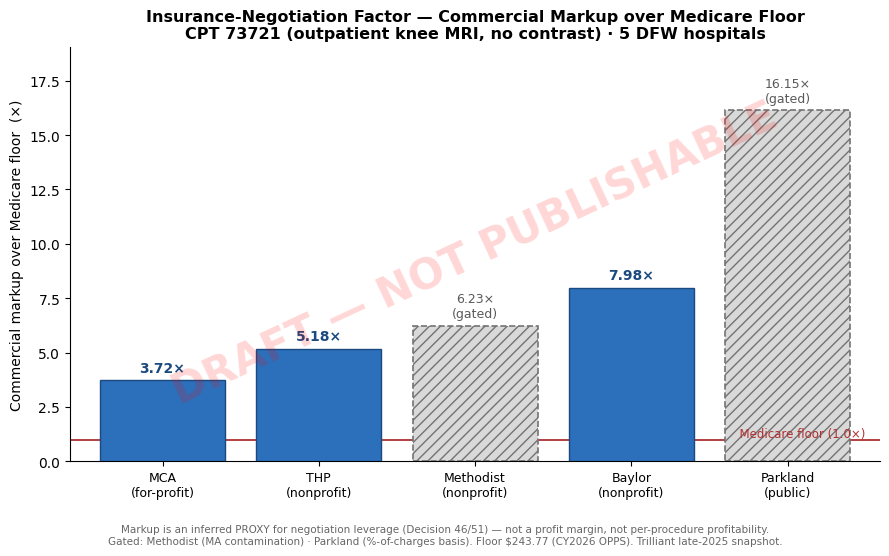

markup ladder (measured commercial / floor):
  MCA          3.72×
  THP          5.18×
  Methodist    6.23×  ← GATED (ghost)
  Baylor       7.98×
  Parkland    16.15×  ← GATED (ghost)

publishable: False  (watermark ON)


In [14]:
# ── NB17 · Insurance-negotiation markup ladder — all five hospitals ──────────
# markup = commercial_median / Medicare floor  (Decision 51 proxy for negotiation
# leverage — NOT a profit margin). Confirmed rungs solid; GATED hospitals render as
# hatched grey ghost bars (measured value shown, but flagged not-publishable).
# Watermark is logic-driven off is_publishable(): it can't be forgotten, can't appear clean.
import matplotlib.pyplot as plt
import numpy as np

# markup straight from the measured commercial rung (gated included, on purpose)
markup = (rungs_real["commercial"] / FLOOR).rename("markup")
gated  = ROSTER["gated"].reindex(markup.index).fillna(False).astype(bool)

# order ascending -> a clean ladder (Parkland's chargemaster ghost tops it out)
order  = markup.sort_values().index
vals   = markup.loc[order].values
isg    = gated.loc[order].values

fig, ax = plt.subplots(figsize=(9, 5.2))
for i, (short, v, g) in enumerate(zip(order, vals, isg)):
    if g:  # gated: hatched grey ghost bar
        ax.bar(i, v, color="0.85", edgecolor="0.45", hatch="///",
               linestyle="--", linewidth=1.2, zorder=2)
        ax.text(i, v + 0.25, f"{v:.2f}×\n(gated)", ha="center", va="bottom",
                fontsize=9, color="0.35")
    else:  # confirmed: solid bar
        ax.bar(i, v, color="#2c6fbb", edgecolor="#1b4a7e", linewidth=1.0, zorder=3)
        ax.text(i, v + 0.25, f"{v:.2f}×", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="#1b4a7e")

# Medicare floor baseline at 1.0×
ax.axhline(1.0, color="#b03030", linestyle="-", linewidth=1.3, zorder=1)
ax.text(len(order) - 0.5, 1.0, "  Medicare floor (1.0×)", ha="right", va="bottom",
        fontsize=8.5, color="#b03030")

ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{s}\n({ROSTER.loc[s,'ownership']})" for s in order], fontsize=9)
ax.set_ylabel("Commercial markup over Medicare floor  (×)", fontsize=10)
ax.set_title("Insurance-Negotiation Factor — Commercial Markup over Medicare Floor\n"
             "CPT 73721 (outpatient knee MRI, no contrast) · 5 DFW hospitals",
             fontsize=11.5, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.04)

# ── auto-watermark off the publish chokepoint ───────────────────────────────
publishable = any(is_publishable(s) for s in ROSTER.index) and bool(MEDIANS_PUBLISHABLE)
if not publishable:
    ax.text(0.5, 0.5, "DRAFT — NOT PUBLISHABLE", transform=ax.transAxes,
            fontsize=30, color="red", alpha=0.16, rotation=25,
            ha="center", va="center", fontweight="bold", zorder=5)

# footer: proxy label + provenance
fig.text(0.5, -0.02,
         "Markup is an inferred PROXY for negotiation leverage (Decision 46/51) — not a profit "
         "margin, not per-procedure profitability.\nGated: Methodist (MA contamination) · "
         "Parkland (%-of-charges basis). Floor $243.77 (CY2026 OPPS). Trilliant late-2025 snapshot.",
         ha="center", va="top", fontsize=7.5, color="0.4")

plt.tight_layout()
plt.show()

print("markup ladder (measured commercial / floor):")
for s in order:
    tag = "  ← GATED (ghost)" if gated.loc[s] else ""
    print(f"  {s:10} {markup.loc[s]:6.2f}×{tag}")
print(f"\npublishable: {publishable}  (watermark {'ON' if not publishable else 'OFF'})")

## Step I — Integrity guard sweep

Final guards (read the *why* of any red flag before trusting it — Day-22 false-alarm lesson;
use rounding-tolerant comparisons, 1e-3):
- all five hospitals present; no real rung is a synthetic leak,
- commercial rung reconciles to NB16 to the penny for the three clean hospitals,
- no **gated** hospital carries a published spread; no clean hospital is missing one,
- no `[SYNTHETIC DATA]` row reaches the real table; watermark state matches `is_publishable()`,
- close with **Integrity: OK** (or a loud, specific failure).


In [15]:
# ── NB17 · Step I — Integrity guard sweep ───────────────────────────────────
# Collect ALL failures (don't die on the first) so the full picture prints. Read
# the WHY of any flag before trusting it — a red line can be a tolerance artifact,
# not a math error (Day-22 false alarm). Rounding-tolerant (1e-3) everywhere.
import numpy as np

TOL = 1e-3
checks = []   # (name, passed, detail)
def _check(name, passed, detail=""):
    checks.append((name, bool(passed), detail))

# ── 1. all five hospitals present ───────────────────────────────────────────
present = list(spreads_real.index)
_check("all five hospitals present",
       set(ROSTER.index) == set(present),
       f"have {sorted(present)}")

# ── 2. no real rung is a synthetic leak (SYN_ names / [SYNTHETIC DATA] stamp) ─
syn_leak = any(str(h).startswith("SYN_") for h in present)
syn_stamp = ("watermark" in spreads_real.columns
             and spreads_real.get("watermark", pd.Series(dtype=object))
                 .astype(str).str.contains(r"\[SYNTHETIC DATA\]").any())
_check("no synthetic rows in the real table",
       not (syn_leak or syn_stamp),
       "clean" if not (syn_leak or syn_stamp) else "SYN_ index or [SYNTHETIC DATA] stamp found")

# ── 3. commercial reconciles to NB16 to the penny (three clean anchors) ──────
recon_detail, recon_ok = [], True
for s, exp in NB16_COMMERCIAL_EXPECTED.items():
    got = float(spreads_real.loc[s, "commercial"])
    ok = abs(got - exp) < 0.005
    recon_ok &= ok
    recon_detail.append(f"{s} {got:.2f} vs {exp:.2f} {'ok' if ok else 'DRIFT'}")
_check("commercial reconciles to NB16", recon_ok, "; ".join(recon_detail))

# ── 3b. markup proxy reconciles to NB16 (rounding-tolerant, the Day-22 trap) ─
mk_detail, mk_ok = [], True
for s, exp in NB16_MARKUP_EXPECTED.items():
    got = float(spreads_real.loc[s, "commercial_over_medicare"])
    ok = abs(round(got, 2) - exp) < TOL      # compare at NB16's stored precision
    mk_ok &= ok
    mk_detail.append(f"{s} {got:.4f}~{exp:.2f} {'ok' if ok else 'DRIFT'}")
_check("markup proxy reconciles to NB16 (tol 1e-3)", mk_ok, "; ".join(mk_detail))

# ── 4. no gated hospital carries a spread; no clean hospital is missing one ──
gate_detail, gate_ok = [], True
for s in ROSTER.index:
    gated = bool(ROSTER.loc[s, "gated"])
    sp = spreads_real.loc[s, SPREAD_COLS]
    if gated:
        ok = sp.isna().all()
        if not ok: gate_detail.append(f"{s}: GATED but spread present")
    else:
        # a clean hospital must have commercial_over_medicare; cash spreads may be
        # NaN legitimately (no cash rung), so only the commercial proxy is required
        ok = not np.isnan(float(sp["commercial_over_medicare"]))
        if not ok: gate_detail.append(f"{s}: clean but commercial spread missing")
    gate_ok &= ok
_check("gate integrity (gated withheld, clean present)", gate_ok,
       "; ".join(gate_detail) if gate_detail else "all correct")

# ── 5. watermark state matches is_publishable() ─────────────────────────────
pub_any = any(is_publishable(s) for s in ROSTER.index) and bool(MEDIANS_PUBLISHABLE)
# with gates up and MEDIANS_PUBLISHABLE=False, nothing may be publishable
_check("publish state consistent (draft while gated)",
       pub_any == (not any(ROSTER["gated"]) and bool(MEDIANS_PUBLISHABLE)),
       f"is_publishable(any)={pub_any}, gated={list(ROSTER.index[ROSTER['gated']])}, "
       f"MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}")

# ── 6. rung sanity: floor is the constant, medians are positive where present ─
floor_ok = (spreads_real["medicare"].round(2) == round(FLOOR, 2)).all()
pos_ok = all(
    (v > 0) for v in spreads_real[["medicaid", "commercial", "cash"]].values.ravel()
    if isinstance(v, (int, float)) and not np.isnan(v)
)
_check("rung sanity (floor constant, medians positive)", floor_ok and pos_ok,
       f"floor_const={floor_ok}, all_positive={pos_ok}")

# ── Report ──────────────────────────────────────────────────────────────────
print("NB17 — Integrity guard sweep\n" + "-"*60)
for name, passed, detail in checks:
    mark = "PASS" if passed else "FAIL"
    print(f"  [{mark}] {name}")
    if detail:
        print(f"         {detail}")

failed = [name for name, passed, _ in checks if not passed]
print("-"*60)
if failed:
    print(f"Integrity: FAIL — {len(failed)} guard(s): {', '.join(failed)}")
    print("  -> read the WHY above before trusting the flag (Day-22: a red line can be")
    print("     a tolerance artifact, not a math error). Do NOT publish.")
else:
    print("Integrity: OK")
    print(f"  5 hospitals · 3 confirmed rungs · 2 gated · MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}")
    print("  NB17_SPREAD safe to hand off (still DRAFT — gates up by design).")

NB17 — Integrity guard sweep
------------------------------------------------------------
  [PASS] all five hospitals present
         have ['Baylor', 'MCA', 'Methodist', 'Parkland', 'THP']
  [PASS] no synthetic rows in the real table
         clean
  [PASS] commercial reconciles to NB16
         MCA 906.53 vs 906.53 ok; THP 1262.69 vs 1262.69 ok; Baylor 1944.56 vs 1944.56 ok
  [PASS] markup proxy reconciles to NB16 (tol 1e-3)
         MCA 3.7188~3.72 ok; THP 5.1798~5.18 ok; Baylor 7.9770~7.98 ok
  [PASS] gate integrity (gated withheld, clean present)
         all correct
  [PASS] publish state consistent (draft while gated)
         is_publishable(any)=False, gated=['Methodist', 'Parkland'], MEDIANS_PUBLISHABLE=False
  [PASS] rung sanity (floor constant, medians positive)
         floor_const=True, all_positive=True
------------------------------------------------------------
Integrity: OK
  5 hospitals · 3 confirmed rungs · 2 gated · MEDIANS_PUBLISHABLE=False
  NB17_SPREAD safe to ha